In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '12' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Dome C Site Data

We set up a Propagator for the Dome C site

In [4]:
Prop = Propagator()

## Taylor Glacier Site Data

We set up a Propagator for the Taylor Glacier site

In [5]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
rho_ice = 0.92
h_bins = np.arange(0, 1001, 1)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
                  elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
                  z_grid=h_bins/rho_ice,
                  h_grid=h_bins,
                  rho_ice=rho_ice,
                  z_close=0,
                 ) # (g/cm^3) density used in Taylor Glacier analysis

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

## Setting Up Time Bins

We separate our time bins into two sections:

- Our **high-sensitivity region** ($\sim$7 kya to present) which affects both Dome C and Taylor Glacier $^{14}$CO levels, and where we use a bin-width of 1 year.

- Our **low-sensitivity region** ($\sim$50 kya to $\sim$7 kya) which only affects the equilibirum level of $^{14}$CO at Taylor Glacier before the start of integration, and where we use a bin-width of 100 years.

In [6]:
# Dome C Time Bins
dt_DC = Prop.dt_int[0]
t_bins_DC = Prop.t_int_bins-Prop.t_int_bins[-1]
t_DC = Prop.t_int-Prop.t_int_bins[-1]
Period_DC = t_bins_DC[-1]-t_bins_DC[0]

# Taylor Glacier Time Bins
dt_TG_short = 1
dt_TG_long = 100
Period_TG_short = Period_DC
Period_TG = 50000

t_bins_TG_short = -np.flip(np.arange(0, Period_TG_short+dt_TG_short, dt_TG_short)) # time integration steps
t_TG_short = (t_bins_TG_short[:-1]+t_bins_TG_short[1:])/2
t_bins_TG_long = -np.flip(np.arange(-t_bins_TG_short[0], Period_TG+dt_TG_long, dt_TG_long))
t_TG_long = (t_bins_TG_long[:-1]+t_bins_TG_long[1:])/2

t_bins_TG = np.concatenate((t_bins_TG_long[:-1], t_bins_TG_short))
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
dt_TG = np.diff(t_bins_TG)

# Full Model Time Bins
Period = Period_TG
t_bins = t_bins_TG
t = t_TG
dt = dt_TG

t_scale = t/Period_DC # time scaled from -1 to 0, with 0=present

f_interp_to_DC = ((t_bins[1:].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC) - (t_bins[:-1].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC))/dt_DC
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

## Load Production Models

We load and structure our Production Models for our two sites

In [7]:
df_Pfast_DC = pd.read_csv('Production Rates/P_fast_DomeC_3233m.csv')
df_Pneg_DC = pd.read_csv('Production Rates/P_neg_DomeC_3233m.csv')
P_14C_DC = np.swapaxes([df_Pfast_DC.T, df_Pneg_DC.T], 0, 1)
model_names_DC = list(df_Pfast_DC.columns)

In [8]:
df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

In [9]:
P_14C = np.concatenate((P_14C_DC, P_14C_TG), axis=-1)
model_names = model_names_DC

In [10]:
alphas = np.arange(0.67,1.01,0.01)

N_alphas = len(alphas)
N_ice = 10
N_atmFit = 2
N_atm = 2
N_int = 11
N_primary = 12

In [11]:
models_MCEq = np.reshape(model_names[:-1], (N_alphas,N_ice,-1))[:,:,N_atmFit:].reshape((N_alphas,N_ice,N_atm,N_int,-1))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model

P_MCEq = P_14C[:-1].reshape((N_alphas,N_ice,-1,*P_14C.shape[1:]))[:,:,N_atmFit:].reshape((N_alphas,N_ice,N_atm,N_int,-1,*P_14C.shape[1:]))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model
#axis5 - Production Mode
#axis6 - Production Depth
P_MCEq.shape

(34, 10, 2, 11, 12, 2, 1254)

In [12]:
models_atmFit = np.reshape(model_names[:-1], (N_alphas,N_ice,-1))[:,:,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit

P_atmFit = P_14C[:-1].reshape((N_alphas,N_ice,-1,*P_14C.shape[1:]))[:,:,:N_atmFit]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit
#axis5 - Production Mode
#axis6 - Depth
P_atmFit.shape

(34, 10, 2, 2, 1254)

In [13]:
m_alpha = [m.split('_')[-1] for m in models_MCEq[:,0,0,0,0]]
m_alpha

['alpha=0.67',
 'alpha=0.68',
 'alpha=0.69',
 'alpha=0.70',
 'alpha=0.71',
 'alpha=0.72',
 'alpha=0.73',
 'alpha=0.74',
 'alpha=0.75',
 'alpha=0.76',
 'alpha=0.77',
 'alpha=0.78',
 'alpha=0.79',
 'alpha=0.80',
 'alpha=0.81',
 'alpha=0.82',
 'alpha=0.83',
 'alpha=0.84',
 'alpha=0.85',
 'alpha=0.86',
 'alpha=0.87',
 'alpha=0.88',
 'alpha=0.89',
 'alpha=0.90',
 'alpha=0.91',
 'alpha=0.92',
 'alpha=0.93',
 'alpha=0.94',
 'alpha=0.95',
 'alpha=0.96',
 'alpha=0.97',
 'alpha=0.98',
 'alpha=0.99',
 'alpha=1.00']

In [14]:
m_ice = [m.split('_')[-2] for m in models_MCEq[0,:,0,0,0]]
m_ice

['GS-ice',
 'ice-Heisinger-False',
 'ice-Heisinger-True',
 'ice-None-False',
 'ice-None-True',
 'H-norm',
 'H-norm',
 'H-norm',
 'H-norm',
 'H-norm']

In [15]:
m_atm = [m.split('_')[-3].split('-')[-1] for m in models_MCEq[0,0,:,0,0]]
m_atm

["('MSIS00', ('SouthPole', 'January'))", "('MSIS00', ('SouthPole', 'July'))"]

In [16]:
m_int = [m.split('_')[-3].split('-')[1] for m in models_MCEq[0,0,0,:,0]]
m_int

['SIBYLL23CPP',
 'SIBYLL23C03',
 'SIBYLL',
 'SIBYLL',
 'SIBYLL',
 'EPOS',
 'QGSJET',
 'QGSJETII03',
 'QGSJET01C',
 'DPMJETIII306',
 'DPMJETIII191']

In [17]:
m_primary = [m.split('_')[0] for m in models_MCEq[0,0,0,0,:]]
m_primary

['GlobalSplineFitBeta',
 'HillasGaisser2012 H3a',
 'HillasGaisser2012 H4a',
 'PolyGonato',
 'GaisserStanevTilav 3-gen',
 'GaisserStanevTilav 4-gen',
 'CombinedGHandHG H3a',
 'ZatsepinSokolskaya pamela',
 'ZatsepinSokolskaya default',
 'GaisserHonda',
 'Thunman',
 'SimplePowerlaw27']

In [18]:
# weights on MCEq models
alpha = np.array([0.75, 0.93])
dalpha = np.array([0.08, 0.07])

w_alpha = np.array([0.5,0.5]) # alpha
w_alphas = np.sum([np.exp(-((alphas-a)/dalpha[i])**2/2)/dalpha[i] * w_alpha[i] for i,a in enumerate(alpha)], axis=0)

w_ice = np.ones(models_MCEq.shape[1]) # ice propagation model
w_ice[5:] = 0.

w_atm = np.ones(models_MCEq.shape[2]) # atmospheric profile

w_int = np.ones(models_MCEq.shape[3]) # interaction model
w_int[:1] = 0.

w_primary = np.ones(models_MCEq.shape[4]) # primary model
w_primary[3:] = 0.

w_MCEq = w_alphas.reshape((-1,1,1,1,1)) * w_ice.reshape((1,-1,1,1,1)) * w_atm.reshape((1,1,-1,1,1)) * w_int.reshape((1,1,1,-1,1)) * w_primary.reshape((1,1,1,1,-1))
w_MCEq /= np.sum(w_MCEq) # normalize the weights

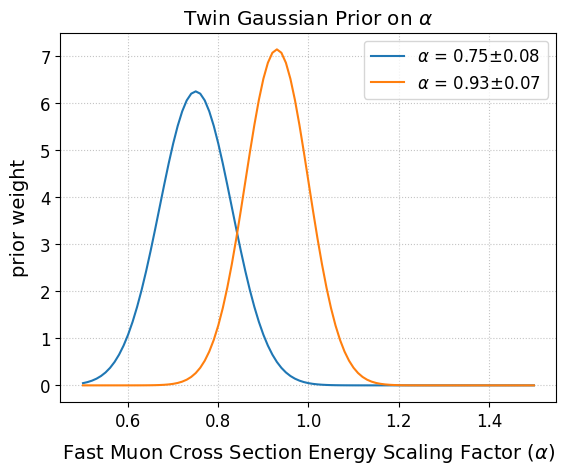

In [19]:
a = np.arange(0.5,1.51,0.01)
for i in range(len(alpha)):
    plt.plot(a, np.exp(-((a-alpha[i])/dalpha[i])**2/2)/dalpha[i] * w_alpha[i], label=r'$\alpha$ = {:.2f}$\pm${:.2f}'.format(alpha[i],dalpha[i]))
#plt.scatter(alphas, w_alphas, label='Modeled Parameters')
plt.xlabel(r'Fast Muon Cross Section Energy Scaling Factor ($\alpha$)')
plt.ylabel('prior weight')
plt.legend()
plt.title(r'Twin Gaussian Prior on $\alpha$')
plt.show()

In [20]:
m_surf = [m.split('_')[0] for m in models_atmFit[0,0,:]]
m_surf

['JN-fit', 'daemonflux']

In [21]:
w_surf = np.ones(models_atmFit.shape[2])

w_atmFit = w_alphas.reshape((-1,1,1)) * w_ice.reshape((1,-1,1)) * w_surf.reshape((1,1,-1))
w_atmFit /= np.sum(w_atmFit)

## Gaussian Uncertainties on Production

### Average

$\langle \vec{P}\rangle$ - the mean production rate in our gaussian approximation

$$\langle\vec{P}\rangle = \int \sum_i \vec{P}_i(\alpha) p_i p(\alpha)d\alpha$$

To find the gaussian uncertainty on $\vec{P}$ with a variable $\alpha$, we approximate that $\vec{P}$ varies linearly with $\alpha$,

$$\vec{P}_i(\alpha) \approx \vec{P}_i(\hat{\alpha}) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha$$

The average $\vec{P}$ can then be evaluated at $\hat{\alpha}$, as

\begin{align*}
    \langle\vec{P}\rangle &= \int \sum_i \vec{P}_i(\hat{\alpha}) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha p_i p(\alpha)d\alpha\\
    &= \sum_i \vec{P}_i(\hat{\alpha}) p_i + \sum_i \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})p_i \int \Delta\alpha p(\alpha)d\alpha\\
    &= \sum_i \vec{P}_i(\hat{\alpha}) p_i\\
\end{align*}

since $\int \Delta\alpha p(\alpha) d\alpha = 0$ when $p(\alpha)$ is even about $\hat{\alpha}$.

### Covariance

$\Sigma_P$ - the covariance on the production rates in our gaussian approximation

$$\Sigma_P = \langle \Delta\vec{P} \Delta\vec{P}^T\rangle$$

$$\Delta \vec{P}_i(\alpha) \equiv \vec{P}_i(\alpha) - \langle \vec{P} \rangle \approx \vec{P}_i(\hat{\alpha}) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha - \langle \vec{P} \rangle = \Delta \vec{P}_i(\alpha) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha$$

\begin{align*}
    \Sigma_P &= \int \sum_{i} \Delta\vec{P}_i(\alpha)\Delta\vec{P}_i(\alpha)^T p_i p(\alpha)d\alpha\\
    &= \int \sum_{i} (\Delta\vec{P}_i(\hat{\alpha}) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha)(\Delta\vec{P}_i(\hat{\alpha}) + \frac{d\vec{P}_i}{d\alpha}(\hat{\alpha})\Delta\alpha)^T p_i p(\alpha)d\alpha\\
    &= \int \sum_{i} [\Delta\vec{P}_i(\hat{\alpha})\Delta\vec{P}_i(\hat{\alpha})^T + (\Delta\vec{P}_i(\hat{\alpha})\frac{d\vec{P}_i}{d\alpha}^T + \frac{d\vec{P}_i}{d\alpha}\Delta\vec{P}_i(\hat{\alpha})^T)\Delta\alpha + \frac{d\vec{P}_i}{d\alpha}\frac{d\vec{P}_i}{d\alpha}^T \Delta\alpha^2] p_i p(\alpha)d\alpha\\
    &= \sum_{i}\Delta\vec{P}_i(\hat{\alpha})\Delta\vec{P}_i(\hat{\alpha})^T p_i + \sum_{i} (\Delta\vec{P}_i(\hat{\alpha})\frac{d\vec{P}_i}{d\alpha}^T + \frac{d\vec{P}_i}{d\alpha}\Delta\vec{P}_i(\hat{\alpha})^T)p_i \int \Delta\alpha\, p(\alpha)d\alpha +  \sum_i \frac{d\vec{P}_i}{d\alpha}\frac{d\vec{P}_i}{d\alpha}^T p_i \int \Delta\alpha^2 \,p(\alpha)d\alpha\\
    &= \sum_{i}\Delta\vec{P}_i(\hat{\alpha})\Delta\vec{P}_i(\hat{\alpha})^T p_i +  \sigma_\alpha^2 \sum_i \frac{d\vec{P}_i}{d\alpha}\frac{d\vec{P}_i}{d\alpha}^T p_i
\end{align*}

since $\int \Delta\alpha^2 \,p(\alpha)d\alpha \equiv \text{Var}(\alpha)$ when $\hat{\alpha}=\langle \alpha \rangle$.

In [22]:
def get_P_alpha_cov(P, w, alphas, a, da):
    P_a = P[np.isclose(alphas, a)][0].reshape((-1,*P.shape[-2:]))
    w_a = w[np.isclose(alphas, a)][0].reshape((-1))
    w_a /= np.sum(w_a)
    Sigma_a = np.cov(P_a.reshape(len(P_a),-1), aweights=w_a, rowvar=False).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    alpha_cut = (alphas<=(a+da)) * (alphas>=(a-da)) * ~np.isclose(alphas, a)
    P_range = P[alpha_cut].reshape((np.sum(alpha_cut),-1,*P.shape[-2:]))
    dP_da = np.average((P_range - P_a)/(alphas[alpha_cut]-a).reshape((-1,1,1,1)), weights=np.exp(-((alphas[alpha_cut]-a)/da)**2/2), axis=0)
    #dSigma_a = np.average(dP_da.reshape((len(w_a),-1,1)) * dP_da.reshape((len(w_a),1,-1)), weights=w_a, axis=0).reshape(*P_a.shape[1:],*P_a.shape[1:]).swapaxes(1,2)
    dSigma_a = np.einsum('aik,ajl,a->ijkl', dP_da, dP_da, w_a, optimize=True)
    
    #P_a_avg = np.average(P_a, weights=w_a, axis=0)
    P_a_cov = Sigma_a + dSigma_a * da**2
    #P_a_std = np.sqrt([np.diag(P_a_cov[0,0]), np.diag(P_a_cov[1,1])])
    
    return P_a_cov

In [23]:
P_avg = np.array([np.average(P[i].reshape((-1,*P.shape[-2:])), weights=w[i].reshape((-1)), axis=0) for P,w in zip([P_MCEq,P_atmFit],[w_MCEq, w_atmFit]) for i in [8,-8]])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Depth
P_avg.shape

(4, 2, 1254)

In [24]:
P_cov = np.array([get_P_alpha_cov(P, w, alphas, a, da) for P,w in zip([P_MCEq,P_atmFit],[w_MCEq, w_atmFit]) for a,da in zip(alpha,dalpha)])
#axis0 - Production ModelSet
#axis1 - Production Mode
#axis2 - Production Mode
#axis3 - Production Depth
#axis4 - Production Depth
P_cov.shape

(4, 2, 2, 1254, 1254)

## Accumulation Model

$\hat{A}$ - accumulation operator

$$\hat{A} = \hat{S}\hat{H}e^{\lambda \hat{t}}$$

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H_i(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present accumulation depth $h$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

In [25]:
def get_H_mat(h, x):
    h_slope = ((x-h[:,:-1])/np.diff(h,axis=1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate([1*(x>=h[:,0])-h_slope[:,0], -np.diff(h_slope, axis=1), h_slope[:,-1]-1*(x>h[:,-1])], axis=1)

In [26]:
h_DC = Prop.h.reshape((1,-1,1,1)) # production depths
x_DC = Prop.h_prime(Prop.h_accum.reshape((1,1,-1,1)), t.reshape((1,1,1,-1))) # accumulation depths

H_DC = get_H_mat(h_DC, x_DC)
#axis0 - Accumulation Model
#axis1 - Production Depth
#axis2 - Accumulation Depth
#axis3 - Time
H_DC.shape

(1, 255, 183, 7724)

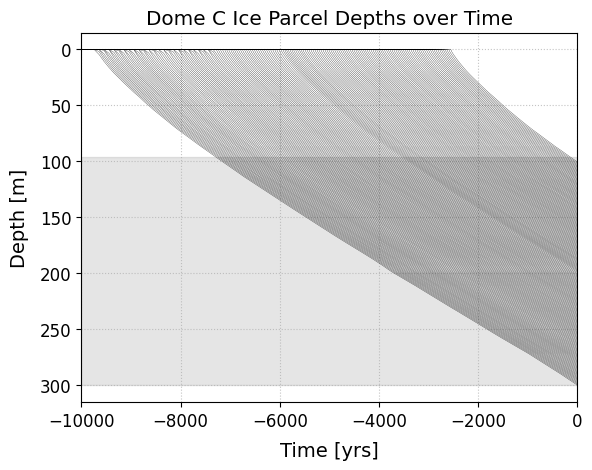

In [27]:
plt.axhspan(Prop.z_close, Prop.z_samp_bins[-1,-1], color='grey', alpha=0.2)
plt.plot(t, Prop.h_to_z(x_DC[0,0].T), c='k', lw=0.2)
plt.xlabel('Time [yrs]')
plt.ylabel('Depth [m]')
plt.xlim(-10000,0)
plt.gca().invert_yaxis()
plt.title('Dome C Ice Parcel Depths over Time')
plt.show()

In [28]:
A_DC = np.einsum('iljk,k->ijkl', H_DC[:,Prop.z>Prop.z_close], np.exp(Prop.lambd*t)*dt)
#axis0 - Accumulation Model
#axis1 - Accumulation Depth
#axis2 - Time
#axis3 - Production Depth
A_DC.shape

(1, 183, 7724, 194)

In [29]:
S_mat_DC = (Prop.h_samp_bins[1].reshape((1,-1))-Prop.h_accum_bins[:-1].reshape((-1,1))).clip(0,Prop.dh_accum.reshape((-1,1))) - (Prop.h_samp_bins[0].reshape((1,-1))-Prop.h_accum_bins[:-1].reshape((-1,1))).clip(0,Prop.dh_accum.reshape((-1,1)))
S_mat_DC /= np.sum(S_mat_DC, axis=0, keepdims=True)
#axis0 - Accumulation Depth
#axis1 - Sample Depth
S_mat_DC.shape

(183, 10)

In [30]:
A_samp_DC = (S_mat_DC.T @ A_DC.T).T
#axis0 - Accumulation Model
#axis1 - Sample Depth
#axis2 - Time
#axis3 - Production Depth
A_samp_DC.shape

(1, 10, 7724, 194)

In [31]:
flow = 'best'
if flow=='best' or flow=='sample':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')
    h_age = flowpath['h_age']
elif flow=='all':
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_all.mat')
    h_age = flowpath['h_age']
else:
    flowpath = loadmat('matlab/MC_14CO_mod/flowpath_trim.mat')
    h_age = np.swapaxes(flowpath['h_trim'], 1,2)
# h_age : ice parcel depth as a function of age [m]
#axis0 - sample depth
#axis1 - flowpath
#axis2 - ice parcel age

age = flowpath['age'][0]
# age : ice parcel ages [years]
#axis0 - ice parcel age
h_age.shape

(8, 1, 861)

In [32]:
h_TG = Prop_TG.h.reshape((1,-1,1,1)) # production depths
x_TG = np.expand_dims(interp1d(-age, -h_age.swapaxes(0,1), bounds_error=False, fill_value=-h_age[:,:,-1].T)(t), axis=1)
# accumulation depths over time, based on end depth

H_TG = get_H_mat(h_TG, x_TG)
#axis0 - Flowpath
#axis1 - Production Depth (TG)
#axis2 - Sample Depth (TG)
#axis3 - Time
H_TG.shape

(1, 999, 8, 7724)

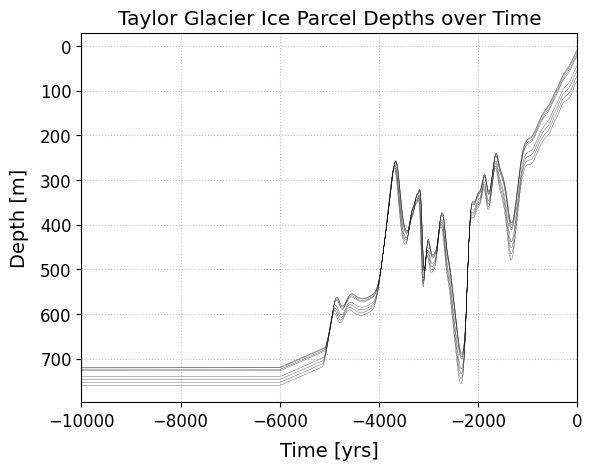

In [33]:
plt.plot(t, Prop_TG.h_to_z(x_TG[0,0].T), c='k', lw=0.2)
plt.xlabel('Time [yrs]')
plt.ylabel('Depth [m]')
plt.xlim(-10000,0)
plt.gca().invert_yaxis()
plt.title('Taylor Glacier Ice Parcel Depths over Time')
plt.show()

In [34]:
A_samp_TG = np.einsum('iljk,k->ijkl', H_TG, np.exp(Prop.lambd*t)*dt)
#axis0 - Flowpath
#axis1 - Sample Depth (TG)
#axis2 - Time
#axis3 - Production Depth (TG)
A_samp_TG.shape

(1, 8, 7724, 999)

In [35]:
A_samp = np.zeros((A_samp_TG.shape[0], A_samp_DC.shape[1]+A_samp_TG.shape[1], A_samp_DC.shape[2], A_samp_DC.shape[3]+A_samp_TG.shape[3]))
A_samp[:,:A_samp_DC.shape[1],:,:A_samp_DC.shape[3]] = A_samp_DC
A_samp[:,A_samp_DC.shape[1]:,:,A_samp_DC.shape[3]:] = A_samp_TG
A_samp.shape

(1, 18, 7724, 1193)

## CR Flux History

$\vec{\phi}$ - CR flux history

In [36]:
def u_to_phi(u):
    # transform uniformly distributed Unit Cube to prior distribution on phi
    return 2*u

In [37]:
phi = np.ones((1,len(t)))

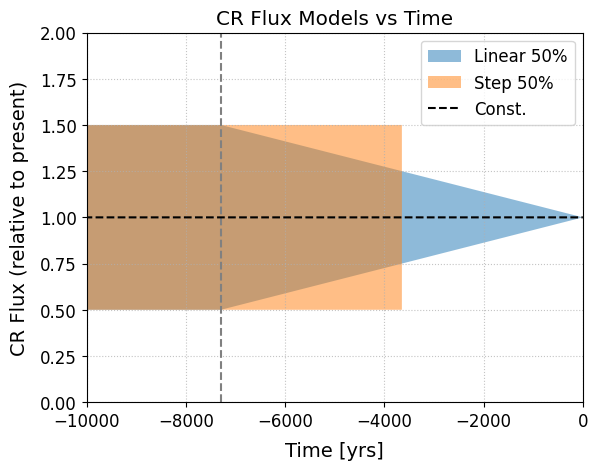

In [38]:
#plt.plot(t, phi.T, c='grey')
plt.axvline(t_bins_DC[0], c='grey', ls='--')
plt.fill_between(t, 1+t_scale.clip(min=-1)*0.5, 1-t_scale.clip(min=-1)*0.5, alpha=0.5, label='Linear 50%')
plt.fill_between(t, 1-0.5*(t_scale<-0.5), 1+0.5*(t_scale<-0.5), alpha=0.5, label='Step 50%')
plt.plot(t, 1+t_scale*0, c='k', ls='--', label='Const.')
plt.xlim(-10000,t_bins_DC[-1])
plt.ylim(0,2)
plt.xlabel('Time [yrs]')
plt.ylabel('CR Flux (relative to present)')
plt.legend()
plt.title('CR Flux Models vs Time')
plt.show()

## f-factors

$\vec{f}$ - production rate scale factors

In [39]:
sigma_E = 4.5e-28
dsigma_E = 2.5e-28

f_tot = 0.1828 * 0.137 #4.4e-3 #<- fake; where did I get this value?
df_tot = 0.1828 * 0.011 #2.6e-3 #<- nope!

Omega_CO = 0.3

f_fast_H = Omega_CO
df_fast_H = Omega_CO * dsigma_E/sigma_E

f_neg_H = Omega_CO
df_neg_H = Omega_CO * df_tot/f_tot

f_avg = np.array([f_fast_H, f_neg_H])
f_cov = np.diag(np.array([df_fast_H, df_neg_H])**2)
f_cov_inv = np.diag(np.array([df_fast_H, df_neg_H])**-2)
f_std = np.diag([df_fast_H, df_neg_H])

In [40]:
df = 0.01
f_fast_bins = np.arange(-.4,1.+df/2,df)
#f_fast_bins = np.array([0.14,0.16])
f_fast = (f_fast_bins[:-1]+f_fast_bins[1:])/2
df_fast = np.diff(f_fast_bins)
f_neg_bins = np.arange(-.4,1.+df/2,df)
#f_neg_bins = np.array([0.14,0.16])
f_neg = (f_neg_bins[:-1]+f_neg_bins[1:])/2
df_neg = np.diff(f_neg_bins)

f = np.array(np.meshgrid(f_fast,f_neg, indexing='ij')).reshape((2,-1)).T
df2 = (df_fast.reshape((-1,1))*df_neg.reshape((1,-1))).reshape((-1))
#axis0 - f-factors
#axis1 - Production Mode
f.shape

(19600, 2)

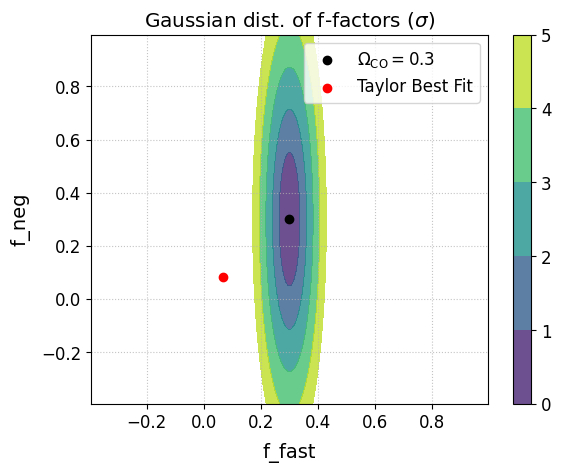

In [41]:
chi2_H = ((f_fast-f_fast_H)/df_fast_H).reshape((-1,1))**2+((f_neg-f_neg_H)/df_neg_H).reshape((1,-1))**2
sig_H = stats.norm.isf(stats.chi2.sf(chi2_H,2)/2)
L_H = np.exp(-chi2_H/2)/np.sqrt((2*np.pi)**2*df_fast_H*df_neg_H)*df_fast.reshape((-1,1))*df_neg.reshape((-1,1))
cont = plt.contourf(f_fast,f_neg, sig_H, alpha=0.8, levels=np.arange(6))
plt.colorbar(cont)
plt.scatter(0.3,0.3,c='k', label=r'$\Omega_{\text{CO}} = 0.3$')
plt.scatter(0.067,0.084, c='r', label='Taylor Best Fit')
plt.xlabel('f_fast')
plt.ylabel('f_neg')
plt.legend()
plt.title(r'Gaussian dist. of f-factors ($\sigma$)')
plt.show()

In [42]:
def u_to_f(u):
    return f_avg + f_std @ scipy.stats.norm.ppf(u)

## Model Priors

In [43]:
def const_prior(f, low=0., high=1.):
    return np.prod((f>=low)*(f<=high)/(high-low))

def inv_prior(f, low=0.01, high=1.):
    return np.prod((1/f)*(f>=low)*(f<=high)/np.log(high/low), axis=-1)

def gauss_prior(f, mean=f_avg, inv_cov=f_cov_inv):
    return np.exp(-np.sum((f-mean)@inv_cov*(f-mean),axis=-1)/2)*np.sqrt(np.linalg.det(inv_cov/2/np.pi))

#Production Model Priors
p_models = np.ones(2)
#p_P = np.ones(P_avg.shape[0])
p_P = (p_models.reshape((-1,1)) * w_alpha.reshape((1,-1))).reshape((-1))[:1]
p_P /= np.sum(p_P)
logp_P = np.log(p_P)
#logp_P.shape

#logp_f = logpf(f) * df?? # prior should be inverse to f
#p_f = inv_prior(f)*df2
p_f = gauss_prior(f)*df2
#p_f /= np.sum(p_f)
logp_f = np.log(p_f)
#logp_f.shape

#logp_phi = logpphi(phi) * dphi?? # prior should be inverse to how wonky the flux looks
p_phi = np.ones(len(phi))
p_phi /= np.sum(p_phi)
logp_phi = np.log(p_phi)
#logp_phi.shape

p_A = np.ones(A_samp.shape[0])[:1]
p_A /= np.sum(p_A)
logp_A = np.log(p_A)
#logp_Z.shape

logp = (logp_P.reshape((-1,1,1,1))+logp_f.reshape((1,-1,1,1))+logp_phi.reshape((1,1,-1,1))+logp_A.reshape((1,1,1,-1))).reshape((-1))
logp.shape

(19600,)

## Predicted $^{14}$CO & Uncertainty

$$\hat{c}_z(\vec{\phi}) = \frac{1}{h_z^+-h_z^-}\int_{h_z^-}^{h_z^+}\int_{t'(h)}^0 \vec{f}\cdot\vec{P}(h'(h,t))\phi(t)e^{\lambda t}\,dt\,dh = \hat{Z}_{zht}\vec{f}_{m}\vec{P}_{mh}\vec{\phi}_t$$

$\hat{c}_z(\vec{\phi})$ - predicted $^{14}$CO concentrations

$h_z$ - sample depth bins (+ upper bound, - lower bound)

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present depth $h$

$t'(h)$ - time when ice parcel at depth $h$ began accumulating $^{14}$CO

$$\Sigma_{\hat{c}}(\vec{\phi},\alpha, \vec{f}, \hat{Z})_{zz'} = (\hat{Z}\vec{\phi})_{zh}(\vec{f}\Sigma_P(\alpha) \vec{f}^T)_{hh'} (\hat{Z}\vec{\phi})^T_{z'h'}$$

$\Sigma_{\hat{c}}$ - covariance in predicted $^{14}$CO from underground spectrum uncertainties

In [44]:
prod_cut = np.concatenate((Prop.z>Prop.z_close, Prop_TG.z>Prop_TG.z_close))

In [45]:
z_samp = np.concatenate((Prop.z_samp, z_samp_TG))

In [46]:
C_pred = np.einsum('lmka,ija->ijklm', phi @ A_samp[:1], f @ P_avg[:1,:,prod_cut], optimize=True).reshape((-1,len(z_samp)))
#axis0 - Production ModelSet
#axis1 - f-factors
#axis2 - CR History
#axis3 - Accumulation Model
#axis4 - Sample Depth
C_pred.shape

(19600, 18)

In [47]:
C_pred_cov = np.einsum('lmkc,lnkd,ja,jb,iabcd->ijklmn',phi@A_samp[:1], phi@A_samp[:1], f, f, P_cov[:1,:,:,prod_cut][:,:,:,:,prod_cut], optimize=True).reshape((-1,len(z_samp),len(z_samp)))
#axis0 - Production ModelSet
#axis1 - f-factors
#axis2 - CR History
#axis3 - Accumulation Model
#axis4 - Sample Depth
#axis5 - Sample Depth
C_pred_cov.shape

(19600, 18, 18)

## Simulated $^{14}$CO Samples

In [48]:
rel_err = 0.02

## log Likelihood Calculation

$$\log L = -\frac{1}{2}(\vec{c}-\hat{c})^T(\Sigma+\Sigma_{\hat{c}})^{-1}(\vec{c}-\hat{c})-\frac{1}{2}\log|2\pi(\Sigma+\Sigma_{\hat{c}})| = -\frac{1}{2}\chi^2 - \frac{1}{2}\log|2\pi(\Sigma+\Sigma_{\hat{c}})|$$

$\vec{c}$ - measured $^{14}$CO concentrations

$\Sigma$ - experimental uncertainties

## Total Likelihood

$$L(\vec{\phi}|\vec{c}) = p(\vec{c}|\vec{\phi}) =  \iiint \frac{e^{-(\vec{c}-\hat{c})^T(\Sigma+\Sigma_{\hat{c}})^{-1}(\vec{c}-\hat{c})/2}}{\sqrt{|2\pi(\Sigma+\Sigma_{\hat{c}})|}} p(\alpha)p(\vec{f})p(\hat{Z})\,d\alpha\, d\vec{f}\, d\hat{Z}$$

## Nested Sampling w/ Dynesty

In [49]:
def sym_sqrt(A):
    # find B s.t. BB^T = A
    vals, vects = np.linalg.eig(A)
    vals[np.abs(vals)<1e-10] = 0
    return np.real(vects * np.sqrt(vals).reshape((*vals.shape[:-1],1,-1)))

In [50]:
def loglike(C_exp):
    C_exp_cov = np.diag((rel_err * C_exp)**2)
    
    dC = C_exp - C_pred
    C_cov = (C_exp_cov + C_pred_cov)#*2
    # To cut down on the number of samples required, we can do the following:
    # Double the uncertainties because they contribute twice.
    # Once in the formula for the logLikelihood
    # And once when we're simulating the samples
    
    #^ This only works under the approximation that the experimental uncertainty that is measured and reported (C_exp_cov)
    # is independent of the true experimental error (Delta_C_exp) and true production error (Delta_P)
    
    logL = logp-np.einsum('ia,iab,ib->i', dC, np.linalg.inv(C_cov), dC, optimize=True)/2 - np.log(np.linalg.det(2*np.pi*C_cov))/2
    norm = np.max(logL)
    
    return np.log(np.sum(np.exp(logL-norm)))+norm

s_P = np.cumsum(p_P)
s_A = np.cumsum(p_A)
s_A_ext = np.append([0],s_A)
s_all = (s_P.reshape((1,-1)) * np.diff(s_A_ext).reshape((-1,1)) + s_A_ext[:-1].reshape((-1,1))).reshape(-1)

def ptform_sample(u):
    # Generates a simulated 14CO sample, with parameters transformed from a draw on the Unit Cube (N-dimensional)
    
    # Unit Cube Parameter Dimension Allocation
    # 0 : Production model (P, Sigma_P)
    # 1 : Accumulation model (A)
    # 2-3 : f-factors (f)
    # +len(t) : CR Flux History (phi) (optional)
    # +len(z_samp) : Production model uncertainties (Delta_C_true) (optional)
    # +len(z_samp) : Experimental error (Delta_C_exp) (optional)
    
    x = np.digitize(u[0], s_all)
    i = x % len(s_P)
    j = x // len(s_P)
    
    f = u_to_f(u[1:3])
    
    #phi = u_to_phi(u[4:4+len(t)])
    phi = np.ones(len(t))
    
    C_pred = (phi @ A_samp[j]) @ (f @ P_avg[i][:,prod_cut])
    C_pred_cov = np.einsum('ic,jd,a,b,abcd->ij',phi@A_samp[j], phi@A_samp[j], f, f, P_cov[i][:,:,prod_cut][:,:,:,prod_cut], optimize=True)
    #C_pred_std = np.einsum('ia,b,baj->ij', phi@A_samp[j], f, P_std[i,:,prod_cut][:,:,prod_cut], optimize=True)
    #C_pred_std = sym_sqrt(C_pred_cov)
    C_pred_std = np.real(scipy.linalg.sqrtm(C_pred_cov))
    
    #Delta_C_true = stats.multivariate_normal.rvs(cov=C_pred_cov, random_state=u[4])
    
    Delta_C_true = C_pred_std @ scipy.stats.norm.ppf(u[3:3+len(z_samp)])
    
    C_true = C_pred + Delta_C_true
    dC_true = rel_err * C_true
    
    Delta_C_exp = dC_true * scipy.stats.norm.ppf(u[3+len(z_samp):3+2*len(z_samp)])
    
    C_exp = C_true + Delta_C_exp
    C_exp_cov = np.diag((rel_err * C_exp)**2)
    
    return C_exp, C_exp_cov

def ptform_pred(u):
    # Unit Cube Parameter Dimension Allocation
    # 0 : Production model (P, Sigma_P)
    # 1 : Accumulation model (A)
    # 2-3 : f-factors (f)
    # +len(t_int) : CR Flux History (phi) (optional)
    
    i = 0
    j = 0
    
    f = u_to_f(u[:2])
    
    #phi = u_to_phi(u[4:4+len(t)])
    phi = np.ones(len(t))
    
    C_pred = (phi @ A_samp[j]) @ (f @ P_avg[i][:,prod_cut])
    C_pred_cov = np.einsum('ic,jd,a,b,abcd->ij',phi@A_samp[j], phi@A_samp[j], f, f, P_cov[i][:,:,prod_cut][:,:,:,prod_cut], optimize=True)
    
    return C_pred, C_pred_cov

def ptform_null(u):
    return u

def loglike_sample(u):
    return loglike(ptform_sample(u))

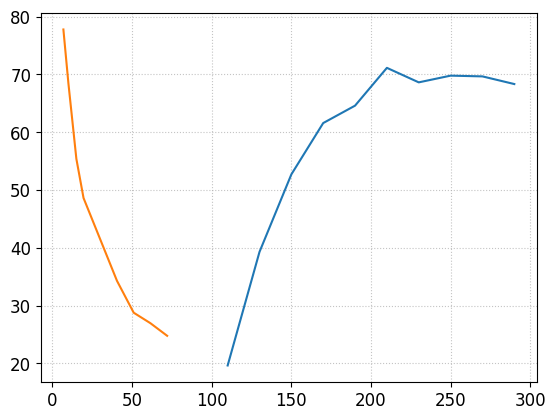

In [51]:
ndim = 3+len(z_samp)*2

u = np.random.random(ndim)
C_exp, C_exp_cov = ptform_sample(u)
#C_exp_cov_inv = np.linalg.inv(C_exp_cov)
#logl_const = -np.log(np.linalg.det(2*np.pi*C_exp_cov))/2
plt.plot(z_samp[:10], C_exp[:10])
plt.plot(z_samp[10:], C_exp[10:])

In [52]:
def loglike_single(x):
    C_pred, C_pred_exp = x
    dC = C_exp-C_pred
    C_cov = C_exp_cov + C_pred_exp
    return -(dC @ np.linalg.inv(C_cov) @ dC)/2 - np.log(np.linalg.det(2*np.pi*C_cov))/2

def loglike_pred(u):
    return loglike_single(ptform_pred(u))

In [53]:
ndim = 2
sampler = dynesty.NestedSampler(loglike_pred, ptform_null, ndim)

In [54]:
sampler.run_nested()
sresults = sampler.results

1358it [33:58,  1.50s/it, +500 | bound: 0 | nc: 1 | ncall: 8240 | eff(%): 24.005 | loglstar:   -inf < -28.980 <    inf | logz: -30.841 +/-  0.033 | dlogz:  0.001 >  0.509]


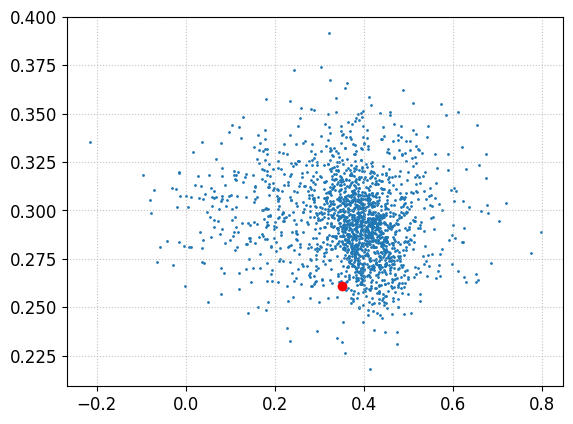

In [66]:
plt.scatter(*(f_avg.reshape((-1,1)) + f_std @ scipy.stats.norm.ppf(sresults.samples.T))[:,-2000:], s=1)
plt.scatter(*u_to_f(u[1:3]), label='True Value', c='r')
#plt.scatter(*f_avg)
#plt.xlim(0.,0.2)
#plt.ylim(0.2,0.4)

In [56]:
loglike(C_exp)

np.float64(-30.82373177536511)

In [57]:
sresults.logz[-1]

np.float64(-30.840787264609475)

In [58]:
sresults.logzerr[-1]

np.float64(0.10034543682971374)

In [59]:
sresults.logl[-1]

np.float64(-28.979609986989555)

In [60]:
(f_avg.reshape((-1,1)) + f_std @ scipy.stats.norm.ppf(sresults.samples.T))[:,-1]

array([0.41478026, 0.26991723])

In [61]:
np.exp(-np.arange(len(sresults.samples))/sresults.nlive)

array([1.        , 0.998002  , 0.99600799, ..., 0.02447752, 0.02442862,
       0.02437981])

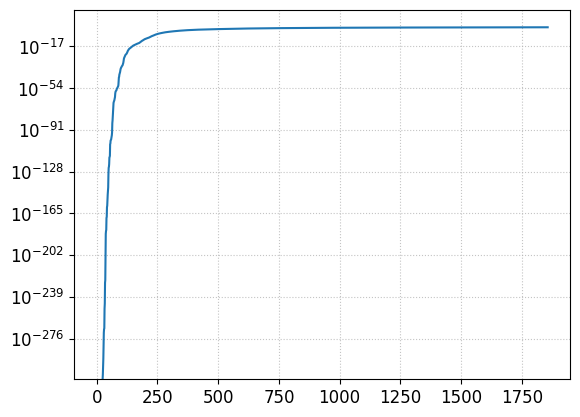

In [62]:
plt.plot(np.exp(sresults.logz-sresults.logz[-1]))
plt.yscale('log')

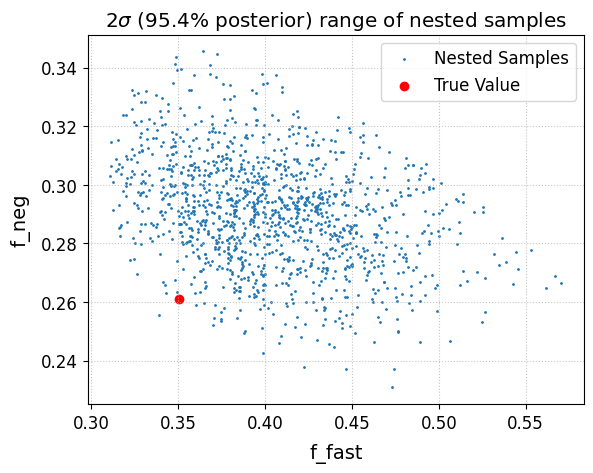

In [69]:
sig = 2

i = np.arange(len(sresults.samples))[(sresults.logz-sresults.logz[-1])>np.log(scipy.stats.norm.sf(sig)*2)][0]
plt.scatter(*(f_avg.reshape((-1,1)) + f_std @ scipy.stats.norm.ppf(sresults.samples.T))[:,i:], s=1, label='Nested Samples')
plt.scatter(*u_to_f(u[1:3]), label='True Value', c='r')
#plt.xlim(0.,0.2)
plt.xlabel('f_fast')
#plt.ylim(0.2,0.4)
plt.ylabel('f_neg')
plt.legend()
plt.title('{}'.format(sig)+'$\sigma$'+' ({:.1f}% posterior) range of nested samples'.format(100-scipy.stats.norm.sf(sig)*200))
plt.show()